# Data Exploration — IMDB Reviews

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

DATA_PATH = "../data/IMDB Dataset.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Class balance

In [3]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Review length distribution

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64


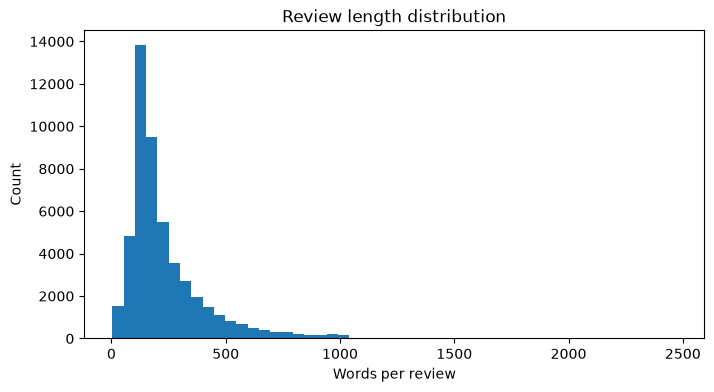

In [4]:
word_counts = df["review"].str.split().apply(len)
print(word_counts.describe())

plt.figure(figsize=(8,4))
plt.hist(word_counts, bins=50)
plt.xlabel("Words per review")
plt.ylabel("Count")
plt.title("Review length distribution")
plt.savefig("../results/review_length_hist.png", dpi=150)
plt.show()

## Common bigrams by sentiment

Top positive bigrams:
     word_1   word_2  count
0       one     best   1626
1      very     good   1593
2      each    other   1296
3      very     well   1235
4       one     most   1178
5      even   though   1099
6      i've     seen   1062
7       all     time   1043
8      ever     seen    967
9     first     time    951
10      too     much    913
11    don't     know    851
12      new     york    822
13  special  effects    802
14     same     time    780

Top negative bigrams:
     word_1   word_2  count
0      ever     seen   1728
1   special  effects   1434
2     waste     time   1413
3     looks     like   1231
4       low   budget   1227
5       too     much   1204
6     don't     know   1194
7      i've     seen   1116
8      much   better   1008
9       one    worst    945
10     look     like    938
11     each    other    925
12     even   though    899
13      bad    movie    894
14     year      old    893


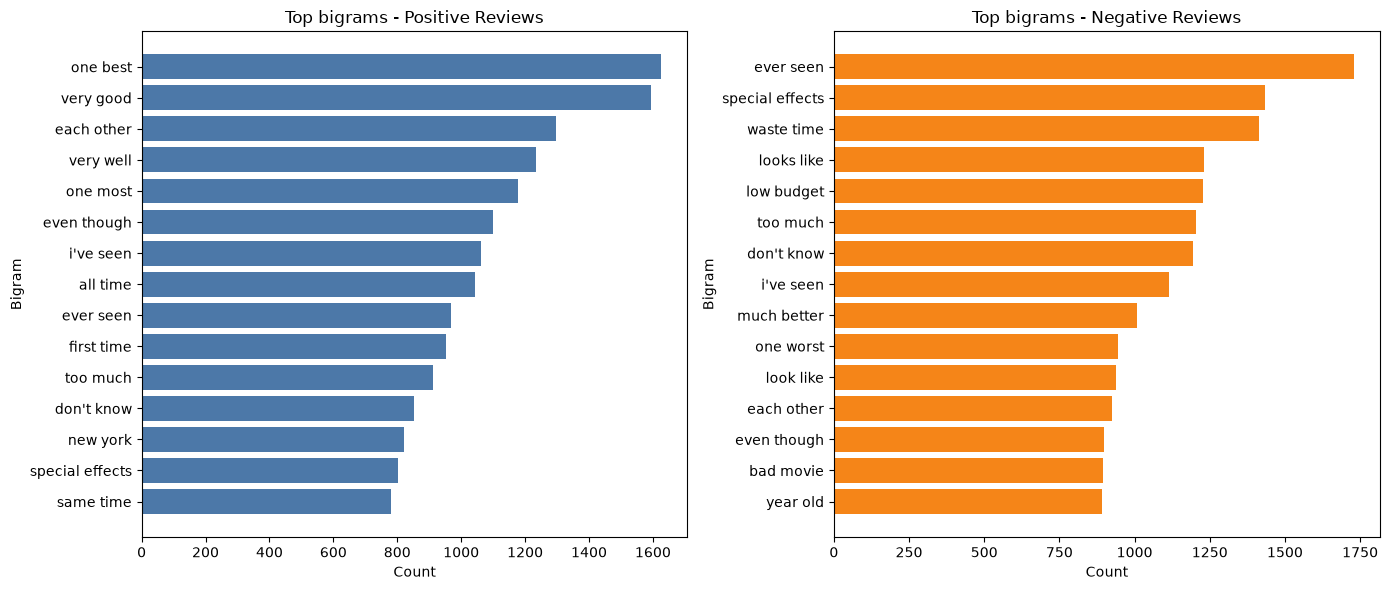

In [5]:
stop_words = {
    "the", "a", "an", "and", "or", "to", "of", "in", "is", "it", "this", "that", "was", "for", "with",
    "as", "but", "on", "are", "be", "have", "has", "had", "i", "you", "he", "she", "they", "we", "at", "by",
    "from", "his", "her", "their", "my", "me", "our", "your", "not", "so", "if", "there", "what", "when",
    "which", "who", "will", "would", "can", "could", "just", "about", "into", "up", "out", "more", "than"
}

def tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())

def clean_tokens(text):
    return [word for word in tokenize(text) if word not in stop_words and len(word) > 2]

def make_bigrams(text_series):
    bigram_counter = Counter()
    for review in text_series:
        tokens = clean_tokens(review)
        bigram_counter.update(zip(tokens, tokens[1:]))
    return bigram_counter

positive_bigrams = make_bigrams(df.loc[df["sentiment"] == "positive", "review"])
negative_bigrams = make_bigrams(df.loc[df["sentiment"] == "negative", "review"])

top_positive_bigrams = pd.DataFrame(
    [(*bigram, count) for bigram, count in positive_bigrams.most_common(15)],
    columns=["word_1", "word_2", "count"],
)
top_negative_bigrams = pd.DataFrame(
    [(*bigram, count) for bigram, count in negative_bigrams.most_common(15)],
    columns=["word_1", "word_2", "count"],
)

print("Top positive bigrams:")
print(top_positive_bigrams)
print("\nTop negative bigrams:")
print(top_negative_bigrams)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, frame, title, color in [
    (axes[0], top_positive_bigrams, "Positive Reviews", "#4C78A8"),
    (axes[1], top_negative_bigrams, "Negative Reviews", "#F58518"),
]:
    labels = frame["word_1"] + " " + frame["word_2"]
    ax.barh(labels[::-1], frame["count"][::-1], color=color)
    ax.set_title(f"Top bigrams - {title}")
    ax.set_xlabel("Count")
    ax.set_ylabel("Bigram")

plt.tight_layout()
plt.show()